In [2]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import joblib
import numpy as np
%matplotlib inline

df = pd.read_csv('swedish_insurance.csv')
df.columns = df.columns.str.strip()
df.head()


,X,Y
0,108,392.5
1,19,46.2
2,13,15.7
3,124,422.2
4,40,119.4


In [3]:
X = df['X']
Y = df['Y']

X_train, x_test, Y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)  # Исправил регистр переменных

model = LinearRegression()
model.fit(X_train.values.reshape(-1, 1), Y_train)  # Ключ: reshape в 2D
pred = model.predict(x_test.values.reshape(-1, 1))

# Оцениваем качество
print(f"Коэффициент: {model.coef_[0]:.2f}")
print(f"Свободный член: {model.intercept_:.2f}")
print(f"R² score: {r2_score(y_test, pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.2f}")


Коэффициент: 3.43
Свободный член: 16.75
R² score: 0.895
RMSE: 29.58


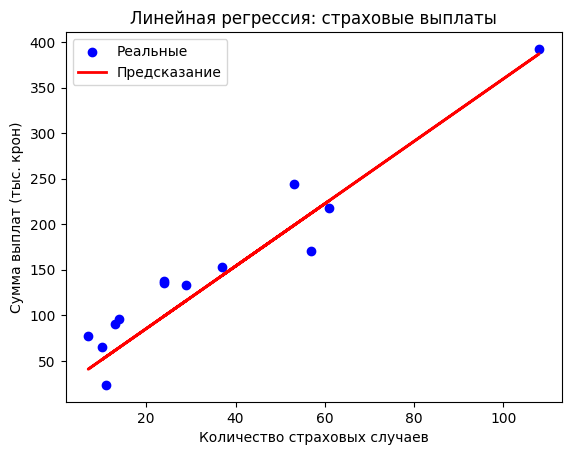

In [4]:
# Визуализация
plt.scatter(x_test, y_test, color='blue', label='Реальные')
plt.plot(x_test, pred, color='red', linewidth=2, label='Предсказание')
plt.xlabel('Количество страховых случаев')
plt.ylabel('Сумма выплат (тыс. крон)')
plt.legend()
plt.title('Линейная регрессия: страховые выплаты')
plt.show()